# Histogram equalization as one-dimensional Monge transport

This notebook generates `fig:monge-histogram-equalization`. A grayscale image defines an empirical measure on intensities,
$$
\alpha_N=\frac1N\sum_{k=1}^N\delta_{I_k}\quad\hbox{on }[0,1].
$$
The monotone Monge map $T=F_\beta^{-1}\circ F_\alpha$ sends this empirical law to a concentrated truncated Gaussian target law $\beta$ near the dark intensities. The displacement interpolation uses
$$
I_{t,k}=(1-t)I_k+tT(I_k).
$$
The exported figure uses the cat photograph from `assets/`: images are arranged on the first row and all histograms on the second row share a common vertical scale.


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

from figure_style import BLUE, RED, interp_color, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
ASSETS = ROOT / "notebooks-figures" / "assets"


## Monotone equalization map

The target law is a truncated Gaussian on $[0,1]$, with mean close to zero. The equalized value of a pixel is obtained by mapping its empirical rank through this target quantile, which is exactly the one-dimensional increasing rearrangement.


In [2]:
from statistics import NormalDist


def load_gray_cat(n=126):
    img = Image.open(ASSETS / "cat.jpg")
    img = ImageOps.grayscale(img).resize((n, n), Image.Resampling.LANCZOS)
    arr = np.asarray(img, dtype=float) / 255.0
    return arr


def equalize_to_truncated_gaussian(arr, mean=0.18, sigma=0.105):
    flat = arr.ravel()
    order = np.argsort(flat, kind="mergesort")
    ranks = np.empty_like(flat, dtype=float)
    ranks[order] = (np.arange(flat.size) + 0.5) / flat.size

    normal = NormalDist(mu=mean, sigma=sigma)
    lo = normal.cdf(0.0)
    hi = normal.cdf(1.0)
    mapped = np.array([normal.inv_cdf(lo + r * (hi - lo)) for r in ranks])
    return np.clip(mapped.reshape(arr.shape), 0.0, 1.0)


img0 = load_gray_cat()
img_eq = equalize_to_truncated_gaussian(img0)
times = [0.0, 1/3, 2/3, 1.0]
images = [(1 - t) * img0 + t * img_eq for t in times]


## Exported image and histogram panels

Each time value is exported as two separate PDFs: the image panel and the histogram panel.  LaTeX assembles the two rows and supplies the time labels.

In [3]:
NAME = "monge-histogram-equalization"
OUT = figure_dir(NAME)

bins = np.linspace(0, 1, 42)
histograms = [np.histogram(img.ravel(), bins=bins, density=True)[0] for img in images]
hist_ymax = 1.08 * max(float(h.max()) for h in histograms)
centers = 0.5 * (bins[:-1] + bins[1:])

target_normal = NormalDist(mu=0.18, sigma=0.105)
lo = target_normal.cdf(0.0)
hi = target_normal.cdf(1.0)
target_pdf = np.array([target_normal.pdf(x) / (hi - lo) for x in centers])

for t, img, hist in zip(times, images, histograms):
    suffix = f"t{int(round(100*t)):03d}"
    color = interp_color(t)

    fig, ax = plt.subplots(figsize=(1.38, 1.38))
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    remove_axes(ax)
    save_pdf(fig, OUT / f"image-{suffix}.pdf", pad_inches=0.005)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(1.38, 0.74))
    ax.fill_between(centers, 0, hist, color=color, alpha=0.28, linewidth=0)
    ax.plot(centers, hist, color=color, lw=1.1)
    ax.plot(centers, target_pdf, color=BLUE, lw=0.75, alpha=0.86)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, hist_ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    save_pdf(fig, OUT / f"hist-{suffix}.pdf", pad_inches=0.005)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


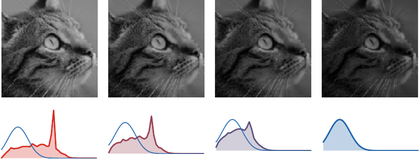

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/monge-histogram-equalization.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-histogram-equalization.png")
display(Image(filename=str(_thumb)))
